# 🧪 Ensemble Learning Lab: Bagging, Boosting, and Stacking (Classification)

## 🎯 Objective
In this task, you will **design, train, evaluate, and compare ensemble learning models** for a **classification problem** using real-world data.  
You will work with **Bagging**, **Boosting**, and **Stacking** techniques and analyze their performance using appropriate evaluation metrics.

---

## 📊 Dataset
- **Source**: :contentReference[oaicite:0]{index=0}  
- **Competition**: *Playground Series – Season 6, Episode 2*  
- **Problem Type**: **Supervised Classification**

🔗 Dataset link:  
[URL](https://www.kaggle.com/competitions/playground-series-s6e2/overview)

> **Note**: You must download the dataset using the Kaggle API or manually upload it to Colab/Jupyter.

---

## 🧠 Models to Implement

### 1️⃣ Bagging
- **Model**: `BaggingClassifier`
- **Base Estimator**: Decision Tree (recommended)
- Key hyperparameters to explore:
  - `n_estimators`
  - `max_samples`
  - `max_features`
  - `bootstrap`

---

### 2️⃣ Boosting Models

#### a) AdaBoost
- **Model**: `AdaBoostClassifier`
- Base estimator: Decision Tree (stump recommended)
- Tune:
  - `n_estimators`
  - `learning_rate`

#### b) Gradient Boosting
- **Model**: `GradientBoostingClassifier`
- Tune:
  - `n_estimators`
  - `learning_rate`
  - `max_depth`
  - `subsample`

#### c) XGBoost
- **Model**: `XGBClassifier`
- Tune:
  - `n_estimators`
  - `learning_rate`
  - `max_depth`
  - `subsample`
  - `colsample_bytree`

> ⚠️ Handle class imbalance if present.

---

### 3️⃣ Stacking
- **Model**: `StackingClassifier`
- **Base learners** (example):
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
- **Meta-learner**:
  - Logistic Regression (recommended)

---

## ⚙️ Task Instructions

### 🔹 Step 1: Data Preparation
- Load training data
- Separate features and target
- Handle missing values (if any)
- Encode categorical variables
- Perform train/validation split
- Apply feature scaling where necessary

---

### 🔹 Step 2: Model Training
- Train **each ensemble model independently**
- Use **cross-validation** where appropriate
- Record training time and key hyperparameters

---

### 🔹 Step 3: Evaluation Metrics
Evaluate all models using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**
- **Confusion Matrix**

---

### 🔹 Step 4: Model Comparison
Create a **comparison table** that includes:
- Model name
- Accuracy
- F1-score
- ROC-AUC
- Training time
- Key observations

---

## 📈 Analysis & Discussion (Required)

Answer the following:
1. Which ensemble method performed best and why?
2. How does **bagging** differ from **boosting** in terms of bias and variance?
3. Did stacking outperform individual ensemble models?
4. Which model would you choose for deployment and why?
5. What are the computational trade-offs between these methods?

---

## 📝 Deliverables
- Fully executable notebook
- Clean, well-documented code
- Final comparison table
- Written analysis and conclusions

---

## ⭐ Bonus (Optional)
- Perform **hyperparameter tuning** using GridSearchCV or RandomizedSearchCV
- Plot **ROC curves** for all models
- Analyze **feature importance** for boosting models

---

🎓 **Learning Outcome**  
By completing this task, you will gain hands-on experience with advanced ensemble techniques and develop a strong intuition for **when and why to use bagging, boosting, or stacking in classification problems**.

In [ ]:
from google.colab import files
uploaded= files.upload()

Saving playground-series-s6e2.zip to playground-series-s6e2.zip


In [ ]:
!unzip -q playground-series-s6e2.zip -d /content/extracted_data

In [ ]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]
extract_path = '/content/extracted_data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Extraction completed.")
print("done\nfiles are in:", extract_path)


Extraction completed.
done
files are in: /content/extracted_data


In [ ]:
!ls -lh /content/extracted_data

total 44M
-rw-r--r-- 1 root root 2.4M Mar  5 15:17 sample_submission.csv
-rw-r--r-- 1 root root  11M Mar  5 15:17 test.csv
-rw-r--r-- 1 root root  31M Mar  5 15:17 train.csv


In [ ]:
import pandas as pd
df = pd.read_csv('/content/extracted_data/train.csv')
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [ ]:
train = pd.read_csv('/content/extracted_data/train.csv')
test = pd.read_csv('/content/extracted_data/test.csv')

train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [ ]:
train.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [ ]:
target = "Heart Disease"
X = train.drop(columns=[target])
y = train[target]

In [ ]:
y.value_counts(normalize=True)

,proportion
Heart Disease,
Absence,0.55166
Presence,0.44834


In [ ]:
X.isnull().sum()

,0
id,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


In [ ]:
X = pd.get_dummies(X, drop_first=True)

Train / Validation Split

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
import numpy as np
np.unique(y)

array([0, 1])

In [ ]:
le.classes_

array(['Absence', 'Presence'], dtype=object)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Model Training

## Bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    random_state=42
)

bagging.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.8,
                  n_estimators=100, random_state=42)

## Boosting

a) AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.1, n_estimators=100, random_state=42)

b) Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42, subsample=0.8)

c) XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

## Stacking

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100)),
        ('gb', GradientBoostingClassifier()),
        ('lr', LogisticRegression(max_iter=1000))
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stack.fit(X_train_scaled, y_train)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier()),
                               ('gb', GradientBoostingClassifier()),
                               ('lr', LogisticRegression(max_iter=1000))],
                   final_estimator=LogisticRegression())

# Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [ ]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1]

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_prob)
    }

# Comparison Table

In [ ]:
results = pd.DataFrame({
    "Bagging": evaluate(bagging, X_val, y_val),
    "AdaBoost": evaluate(ada, X_val, y_val),
    "GradientBoosting": evaluate(gb, X_val, y_val),
    "XGBoost": evaluate(xgb, X_val, y_val),
    "Stacking": evaluate(stack, X_val_scaled, y_val)
}).T

results

,Accuracy,Precision,Recall,F1,ROC-AUC
Bagging,0.880452,0.873198,0.857942,0.865503,0.946501
AdaBoost,0.880698,0.897094,0.828999,0.861703,0.949649
GradientBoosting,0.888421,0.882836,0.866067,0.874371,0.954554
XGBoost,0.889246,0.883304,0.867590,0.875376,0.955542
Stacking,0.888214,0.882312,0.866209,0.874186,0.954472


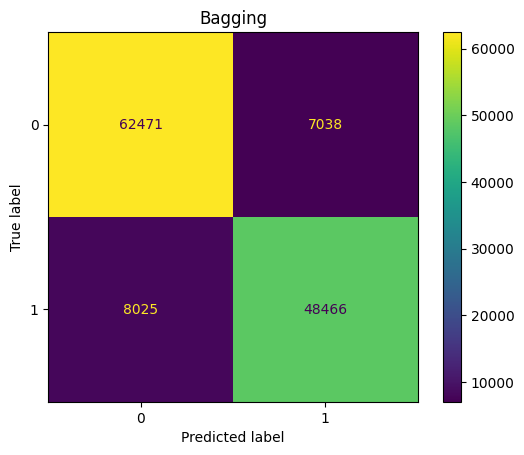

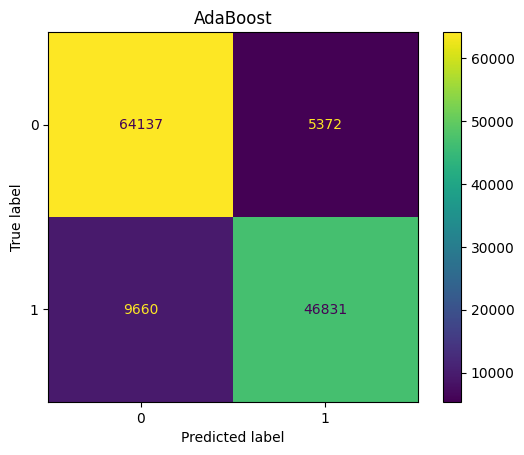

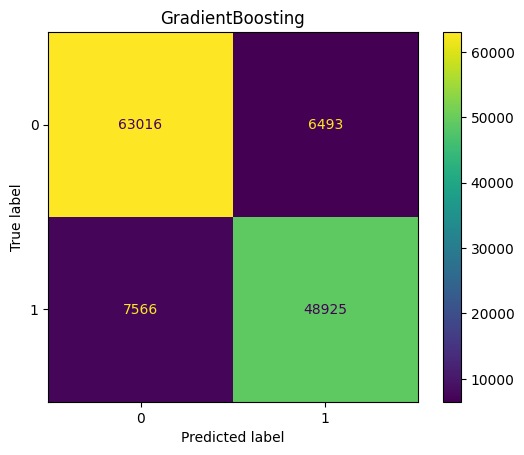

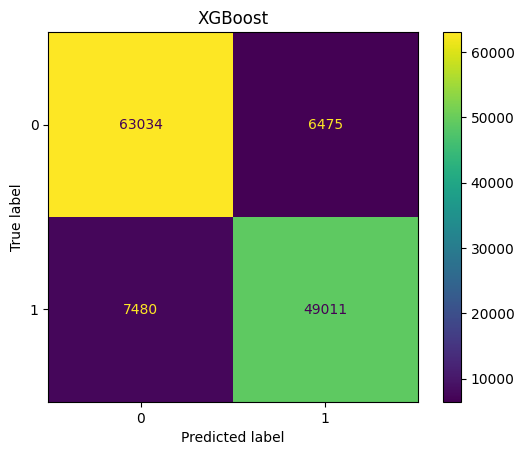

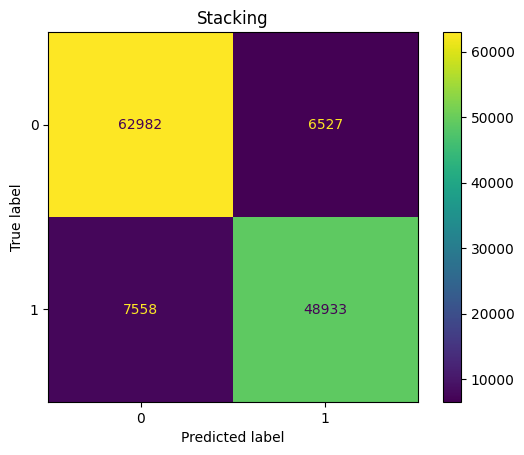

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Bagging": bagging,
    "AdaBoost": ada,
    "GradientBoosting": gb,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_val)

    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.title(name)
    plt.show()
y_pred = stack.predict(X_val_scaled)
ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.title("Stacking")
plt.show()

In [ ]:
X_test = pd.get_dummies(test, drop_first=True)

In [ ]:
for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[X.columns]

In [33]:
y_test_pred = xgb.predict_proba(X_test)[:,1]

In [38]:
if "id" in test.columns:
    submission = pd.DataFrame({
        "id": test["id"],
        "Heart Disease": y_test_pred
    })
else:
    submission = pd.DataFrame({
        "Heart Disease": y_test_pred
    })

In [39]:
submission.to_csv("sample_submission.csv", index=False)

print("✅ sample_submission.csv جاهز للرفع على Kaggle")


✅ sample_submission.csv جاهز للرفع على Kaggle


In [40]:
submission.head()

,id,Heart Disease
0,630000,0.918291
1,630001,0.007394
2,630002,0.979818
3,630003,0.005106
4,630004,0.209352


In [41]:
from google.colab import files
files.download("sample_submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>